In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [5]:
# A tensor is a multi-dimensional array

# Scalar (0D Tensor)
scalar = tf.constant(10)

# Vector (1D Tensor)
vector = tf.constant([1, 2, 3, 4])

# Matrix (2D Tensor)
matrix = tf.constant([[1,2],
                      [3,4]])

# 3D Tensor
tensor3d = tf.constant([
    [[1,2],[3,4]],
    [[5,6],[7,8]]
])

print("Scalar:")
print(scalar)

print("\nVector:")
print(vector)

print("\nMatrix:")
print(matrix)

print("\n3D Tensor:")
print(tensor3d)

Scalar:
tf.Tensor(10, shape=(), dtype=int32)

Vector:
tf.Tensor([1 2 3 4], shape=(4,), dtype=int32)

Matrix:
tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)

3D Tensor:
tf.Tensor(
[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]], shape=(2, 2, 2), dtype=int32)


In [6]:
print("Scalar Shape:", scalar.shape)
print("Vector Shape:", vector.shape)
print("Matrix Shape:", matrix.shape)
print("3D Tensor Shape:", tensor3d.shape)

Scalar Shape: ()
Vector Shape: (4,)
Matrix Shape: (2, 2)
3D Tensor Shape: (2, 2, 2)


In [7]:
# Load handwritten digit dataset

mnist = keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


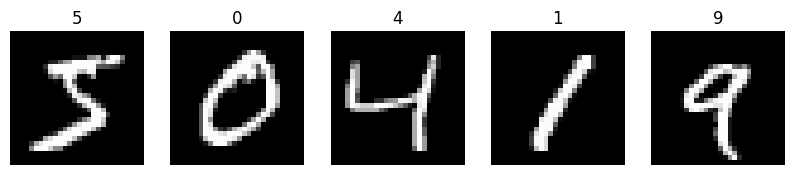

In [8]:
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

In [9]:
# Scale pixel values between 0 and 1

x_train = x_train / 255.0
x_test = x_test / 255.0

In [10]:
model = keras.Sequential([
    
    # Flatten converts 28x28 image into 784 values
    layers.Flatten(input_shape=(28,28)),
    
    # Hidden Layer
    layers.Dense(128, activation='relu'),
    
    # Output Layer
    layers.Dense(10, activation='softmax')
])

model.summary()

c:\Users\Prathmesh\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
x = tf.constant([-2., -1., 0., 1., 2.])

print("Input:")
print(x.numpy())

print("\nReLU:")
print(tf.nn.relu(x).numpy())

print("\nSigmoid:")
print(tf.nn.sigmoid(x).numpy())

print("\nTanh:")
print(tf.nn.tanh(x).numpy())

print("\nSoftmax:")
print(tf.nn.softmax(x).numpy())

Input:
[-2. -1.  0.  1.  2.]

ReLU:
[0. 0. 0. 1. 2.]

Sigmoid:
[0.11920294 0.2689414  0.5        0.73105854 0.8807971 ]

Tanh:
[-0.9640276 -0.7615942  0.         0.7615942  0.9640276]

Softmax:
[0.01165623 0.03168492 0.08612853 0.23412165 0.63640857]


In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [14]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9199 - loss: 0.2876 - val_accuracy: 0.9535 - val_loss: 0.1627
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9609 - loss: 0.1307 - val_accuracy: 0.9664 - val_loss: 0.1175
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9739 - loss: 0.0890 - val_accuracy: 0.9692 - val_loss: 0.1040
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9799 - loss: 0.0665 - val_accuracy: 0.9708 - val_loss: 0.0962
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9849 - loss: 0.0502 - val_accuracy: 0.9721 - val_loss: 0.0969


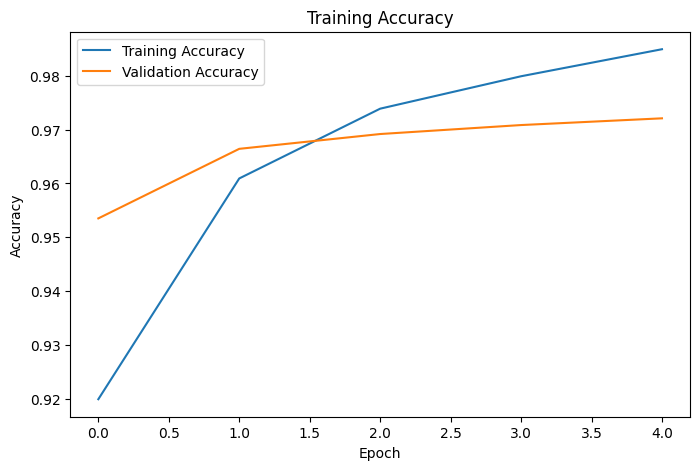

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()
plt.show()

In [16]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9724 - loss: 0.0889
Test Loss: 0.08893128484487534
Test Accuracy: 0.9724000096321106


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step
Predicted Digit: 7
Actual Digit: 7


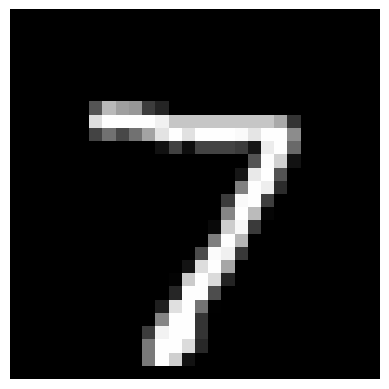

In [17]:
predictions = model.predict(x_test)

print("Predicted Digit:", np.argmax(predictions[0]))
print("Actual Digit:", y_test[0])

plt.imshow(x_test[0], cmap='gray')
plt.axis("off")
plt.show()